In [1]:
import numpy as np
import os
import xarray as xr
import Ngl
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, HourLocator, date2num, num2date

# vertical_int = np.trapz(integrand, x=ds.lev, axis=1)

# constants
g = 9.81

DIR = '/glade/derecho/scratch/nforcone/CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Perturbation_New/run'
FILE_m = 'CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Perturbation_New.cam.h0a.0001-01-31-00000.nc'
FILE_d = 'CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Perturbation_New.cam.h1a.0001-01-02-00000.nc'
monthly = xr.open_dataset(os.path.join(DIR, FILE_m), decode_cf=False)
daily = xr.open_dataset(os.path.join(DIR, FILE_d), decode_cf=False)
daily

<xarray.Dataset> Size: 19GB
Dimensions:       (lat: 129, lon: 256, lev: 26, ilev: 27, trop_pref: 26,
                   trop_prefi: 27, time: 1090, nbnd: 2, chars: 8)
Coordinates:
  * lat           (lat) float64 1kB -90.0 -88.59 -87.19 ... 87.19 88.59 90.0
  * lon           (lon) float64 2kB 0.0 1.406 2.812 4.219 ... 355.8 357.2 358.6
  * lev           (lev) float64 208B 3.545 7.389 13.97 ... 929.6 970.6 992.6
  * ilev          (ilev) float64 216B 2.194 4.895 9.882 ... 956.0 985.1 1e+03
  * trop_pref     (trop_pref) float64 208B 3.545 7.389 13.97 ... 970.6 992.6
  * trop_prefi    (trop_prefi) float64 216B 2.194 4.895 9.882 ... 985.1 1e+03
  * time          (time) float64 9kB 0.5 1.5 2.5 ... 1.088e+03 1.09e+03
Dimensions without coordinates: nbnd, chars
Data variables: (12/20)
    w             (lat) float64 1kB ...
    hyam          (lev) float64 208B ...
    hybm          (lev) float64 208B ...
    hyai          (ilev) float64 216B ...
    hybi          (ilev) float64 216B ...
    date          (time) int32 4kB ...
    ...            ...
    mdt           int32 4B ...
    OMEGA         (time, lev, lat, lon) float32 4GB ...
    Q             (time, lev, lat, lon) float32 4GB ...
    T             (time, lev, lat, lon) float32 4GB ...
    U             (time, lev, lat, lon) float32 4GB ...
    V             (time, lev, lat, lon) float32 4GB ...
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Perturbation_New
    logname:           nforcone
    host:              dec1496
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/s...
    topography_file:   bnd_topo
    model_doi_url:     not_set
    time_period_freq:  day_1

## Kinetic Energy

In [2]:
U = daily.U
V = daily.V
lat = daily.lat
time = daily.time
integrand = 0.5 * (U**2 + V**2)

# integrate over model level
integrate1 = integrand.integrate(coord='lev') / g

# integrate over latitude
integrate2 = (np.cos(np.deg2rad(lat)) * integrate1).integrate(coord='lat') * (np.pi / 180)

# integrate over longitude
integrate3 = integrate2.integrate(coord='lon') * (np.pi / 180)

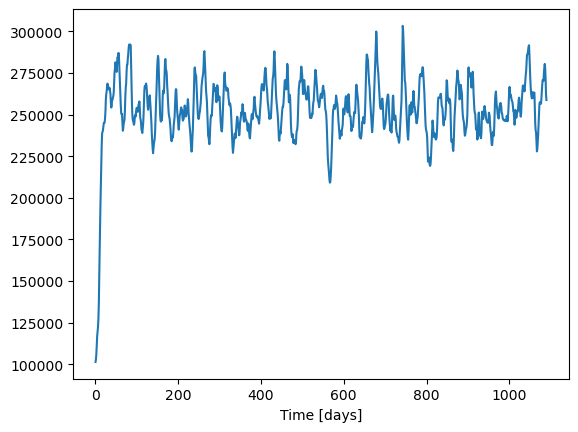

In [3]:
plt.figure(1)
plt.xlabel('Time [days]')
plt.plot(time, integrate3)

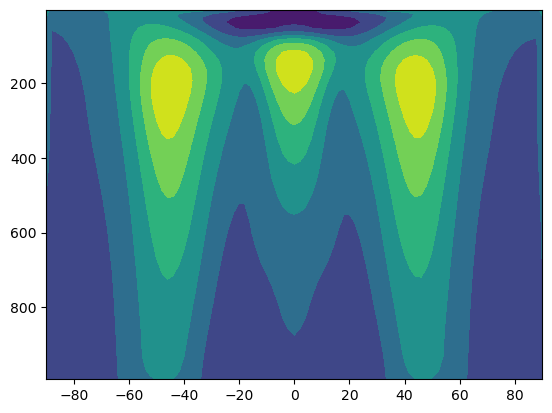

In [4]:
fig3 = plt.figure(3)
ax3 = fig3.add_subplot()
ax3.contourf(monthly.lat, monthly.lev, monthly.U.mean(dim=['time','lon']))
ax3.invert_yaxis()

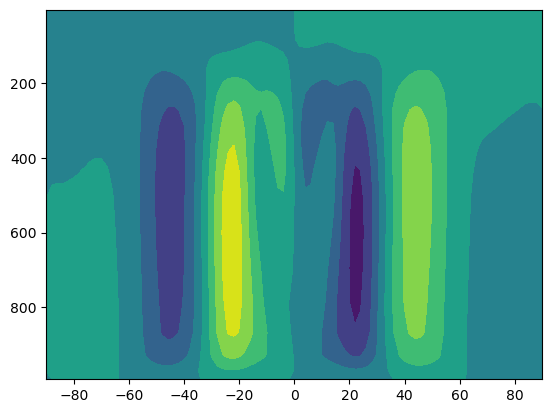

In [5]:
a = 6371000  # m

v_zonal_mean = monthly.V.mean(dim=['time','lon'])
levels = monthly.lev

vertical_int = []
for i in range(len(levels)):
    integrate = np.trapz(v_zonal_mean[i:], levels[i:] * 100, axis=0)
    vertical_int.append(integrate)

numLats = len(monthly.lat)
cos_phi = np.zeros(shape=(1, numLats))
for phi, i in zip(monthly.lat, range(numLats)):
    cos_phi[0, i] = np.cos(np.deg2rad(phi))

StreamFunc = a * 2 * np.pi * (1 / g) * cos_phi * np.asarray(vertical_int)

fig4 = plt.figure(4)
ax4 = fig4.add_subplot()
ax4.contourf(monthly.lat, monthly.lev, StreamFunc)
ax4.invert_yaxis()

## Walker

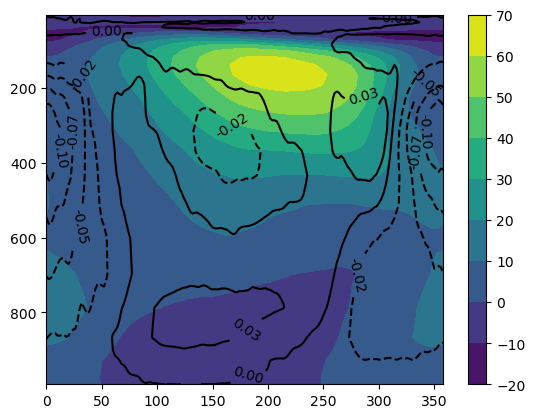

In [25]:
# u_meridional_mean = monthly.U.sel(lat=0, method='nearest').mean(dim='time')
# u_meridional_mean = monthly.U.mean(dim=['time', 'lat'])

# vertical_int_2 = []
# for i in range(len(levels)):
#     integrate_2 = np.trapz(u_meridional_mean[i:], levels[i:] * 100, axis=0)
#     vertical_int_2.append(integrate_2)

# StreamFunc_2 = a * 2 * np.pi * (1 / g) * np.asarray(vertical_int_2)

def fmt(x):
    return f"{x:.2f}"

fig5 = plt.figure(5)
ax5 = fig5.add_subplot()
cf5 = ax5.contourf(monthly.lon, monthly.lev, monthly.U.sel(lat=0, method='nearest').mean(dim=['time']))
cf_Omega = ax5.contour(monthly.lon, monthly.lev, monthly.OMEGA.sel(lat=0, method='nearest').mean(dim=['time']), colors='k')
plt.colorbar(cf5, ax=ax5)
ax5.clabel(cf_Omega, cf_Omega.levels, fmt=fmt)
ax5.invert_yaxis()

$$\overline{vT}=\overline{v}\overline{T}+\overline{v'T'}$$

$$[\overline{vT}]=[\overline{v}\overline{T}]+[\overline{v'T'}]$$

overbar is time mean, ' is time anomaly

$$[vT]=[v][T]+[v^*T^*]$$

[ ] is zonal mean, * is zonal anomaly

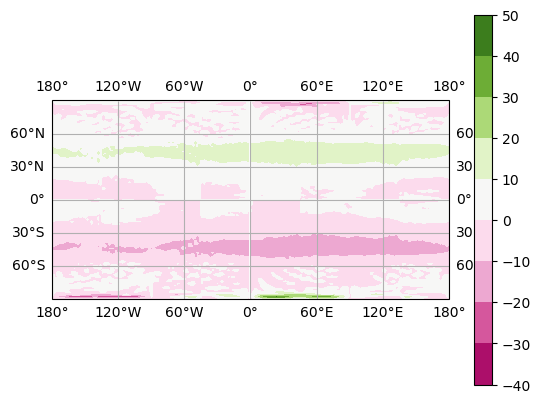

In [39]:
import cartopy
import cartopy.crs as ccrs

VT_mon = monthly.VT.mean(dim='time')
V_mon = monthly.V.mean(dim='time')
T_mon = monthly.T.mean(dim='time')
V_prime_T_prime = VT_mon - V_mon*T_mon
fig6 = plt.figure(6)
ax6 = fig6.add_subplot(projection=ccrs.PlateCarree())
ax6.gridlines(draw_labels=True)
cf6 = ax6.contourf(monthly.lon, monthly.lat, V_prime_T_prime[-1,:,:], cmap='PiYG')
plt.colorbar(cf6, ax=ax6)